# Process bulk counts table

1. Annotate columns (samples) in a way that time point and replicate are annotated
2. Remove rRNA genes
3. Perform TPM normalization and alternatively also raw counts

In [1]:
# Use miniconda environment Jupyter_new for running this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tools import *
import warnings
warnings.filterwarnings('ignore')

## 1 Load the dataset and annotation

In [2]:
bulkPath = '../nf_output/countData/countData.tsv' 
metaPath = '../SraRunTable.csv' # metadata from SRA
gffPath = '../nf_output/alignments/dualGenome.gff3' # output from nf pipeline

In [3]:
# Load data
df_initial = pd.read_csv(bulkPath, sep = '\t', comment='#', index_col=0)
metadata = pd.read_csv(metaPath)

In [4]:
df_initial

,Chr,Start,End,Strand,Length,SRR9623113_sorted.bam,SRR9623111_sorted.bam,SRR9623115_sorted.bam,SRR9623114_sorted.bam,SRR9623109_sorted.bam,SRR9623110_sorted.bam,SRR9623112_sorted.bam,SRR9623108_sorted.bam
Geneid,,,,,,,,,,,,,
gene-FLV31_RS20270,NZ_VIQP01000010.1,4,165,+,162,0,1,3,1,3,1,1,0
gene-FLV31_RS17065,NZ_VIQP01000010.1,238,322,-,85,0,3,2,3,12,0,1,22
gene-FLV31_RS17070,NZ_VIQP01000010.1,546,1181,+,636,0,22,31,7,107,37,2,438
gene-FLV31_RS17075,NZ_VIQP01000010.1,1262,2455,+,1194,7,35,33,18,230,70,12,980
gene-FLV31_RS17080,NZ_VIQP01000010.1,2452,3573,-,1122,13,105,57,40,387,147,7,1878
...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-N356_gp107,NC_021806.1,97531,97752,-,222,166,8069,1843,1103,3273,7655,3,4
gene-N356_gp108,NC_021806.1,98111,98317,+,207,134584,32254,229601,236786,124471,74140,230464,143577
gene-N356_gp109,NC_021806.1,98455,98706,+,252,39285,5606,77888,65534,29470,8555,55287,64213


In [5]:
metadata

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,DATASTORE filetype,...,Organism,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,time_point,tissue
0,SRR9623108,RNA-Seq,84,2148668676,PRJNA552041,SAMN12172989,765552613,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:40:00Z,1,GSM3912979,infected cells,SRP212690,40 min after infection,Cellulophaga baltica culture infected with pha...
1,SRR9623109,RNA-Seq,84,1349458152,PRJNA552041,SAMN12172988,477871456,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:37:00Z,1,GSM3912980,infected cells,SRP212690,90 min after infection,Cellulophaga baltica culture infected with pha...
2,SRR9623110,RNA-Seq,84,1405748652,PRJNA552041,SAMN12172987,495382018,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:35:00Z,1,GSM3912981,infected cells,SRP212690,140 min after infection,Cellulophaga baltica culture infected with pha...
3,SRR9623111,RNA-Seq,84,1181079900,PRJNA552041,SAMN12172986,417292592,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:36:00Z,1,GSM3912982,infected cells,SRP212690,190 min after infection,Cellulophaga baltica culture infected with pha...
4,SRR9623112,RNA-Seq,84,1417270176,PRJNA552041,SAMN12172985,502141850,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:37:00Z,1,GSM3912983,infected cells,SRP212690,40 min after infection from rifampicine-treate...,Cellulophaga baltica culture infected with pha...
5,SRR9623113,RNA-Seq,84,1103758992,PRJNA552041,SAMN12172984,398729644,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:36:00Z,1,GSM3912984,infected cells,SRP212690,90 min after infection from rifampicine-treate...,Cellulophaga baltica culture infected with pha...
6,SRR9623114,RNA-Seq,84,1320878496,PRJNA552041,SAMN12172983,466737979,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:37:00Z,1,GSM3912985,infected cells,SRP212690,140 min after infection from rifampicine-treat...,Cellulophaga baltica culture infected with pha...
7,SRR9623115,RNA-Seq,84,1231272672,PRJNA552041,SAMN12172982,436383077,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:36:00Z,1,GSM3912986,infected cells,SRP212690,190 min after infection from rifampicine-treat...,Cellulophaga baltica culture infected with pha...


## 2 Format the dataset

### 2.1 Annotate sample names

Issue now is that the metadata does not properly annotate sample names. Thus, this will be done manually by adding another sample name column to the metadata.

In [6]:
# Match GSM IDs and SampleNames inferred from GEO

sampleDict = {'SRR9623108': '40_no_rif', 'SRR9623109': '90_no_rif', 'SRR9623110': '140_no_rif', 'SRR9623111': '190_no_rif', 'SRR9623112': '40_rif', 'SRR9623113': '90_rif',
              'SRR9623114': '140_rif', 'SRR9623115': '190_rif'}

In [7]:
metadataFull = annotateData(metadata, sampleDict)

In [8]:
metadata.head(1)

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,DATASTORE filetype,...,Organism,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,time_point,tissue
0,SRR9623108,RNA-Seq,84,2148668676,PRJNA552041,SAMN12172989,765552613,GEO,public,"fastq,run.zq,sra",...,Cellulophaga baltica,ILLUMINA,2020-07-05T00:00:00Z,2019-07-02T17:40:00Z,1,GSM3912979,infected cells,SRP212690,40 min after infection,Cellulophaga baltica culture infected with pha...


In [9]:
metadataFull.head(1)

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,DATASTORE filetype,...,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,time_point,tissue,SampleID,SampleNames
SampleID,,,,,,,,,,,,,,,,,,,,,
SRR9623108_sorted.bam,SRR9623108,RNA-Seq,84,2148668676,PRJNA552041,SAMN12172989,765552613,GEO,public,"fastq,run.zq,sra",...,2020-07-05T00:00:00Z,2019-07-02T17:40:00Z,1,GSM3912979,infected cells,SRP212690,40 min after infection,Cellulophaga baltica culture infected with pha...,SRR9623108_sorted.bam,40_no_rif


Add correct sample names.

In [10]:
df = changeColnames(df_initial.iloc[:,5:df_initial.shape[1]], metadataFull)
df = df[['40_no_rif', '90_no_rif', '140_no_rif', '190_no_rif', '40_rif', '90_rif', '140_rif', '190_rif']]
df

SampleNames,40_no_rif,90_no_rif,140_no_rif,190_no_rif,40_rif,90_rif,140_rif,190_rif
Geneid,,,,,,,,
gene-FLV31_RS20270,0,3,1,1,1,0,1,3
gene-FLV31_RS17065,22,12,0,3,1,0,3,2
gene-FLV31_RS17070,438,107,37,22,2,0,7,31
gene-FLV31_RS17075,980,230,70,35,12,7,18,33
gene-FLV31_RS17080,1878,387,147,105,7,13,40,57
...,...,...,...,...,...,...,...,...
gene-N356_gp107,4,3273,7655,8069,3,166,1103,1843
gene-N356_gp108,143577,124471,74140,32254,230464,134584,236786,229601
gene-N356_gp109,64213,29470,8555,5606,55287,39285,65534,77888


### 2.2 Remove rRNA genes

2.1 Process gff3 files for front end processing

In [11]:
# Load gff3 and split into genes and CDS dfs
gff3 = pd.read_csv(gffPath, sep='\t', header = None, comment='#')
gff3.columns=["seq_id", "source", "type", "start", "end", "phase", "strand", "score", "attributes"]
gff3_genes = gff3.loc[gff3["type"] == 'gene']

# Column formating for genes
gff3_genes = gff3_genes.reset_index(drop=True)
dct_genes = gff3_genes["attributes"].str.split(';').apply(lambda items: dict(item.split('=', 1) for item in items if '=' in item))
cols_to_keep = ['ID', 'Name', 'gbkey', 'gene_biotype', 'locus_tag', 'gene']
gff3_genes = pd.concat([gff3_genes, pd.json_normalize(dct_genes)[cols_to_keep]], axis=1)

# Generate locus_tag, product dictonary over all different feature types
attrs = gff3["attributes"].str.split(";", expand=True)
attrs_dicts = attrs.apply(lambda row: {item.split("=")[0]: item.split("=")[1] for item in row if "=" in str(item)}, axis=1)
attrs_df = pd.json_normalize(attrs_dicts)
attrs_df = attrs_df.dropna(subset=["locus_tag", "product"])
locus_product_dict = dict(zip(attrs_df["locus_tag"], attrs_df["product"]))

# Add gene product, if not stated in gff3, fill with gene_biotype
gff3_genes["product"] = gff3_genes["locus_tag"].map(locus_product_dict)
gff3_genes["product"] = gff3_genes["product"].fillna("other")
# gff3_genes["product"] = gff3_genes["product"].fillna(gff3_genes["gene_biotype"])

# If gene = NA, take from ID column
gff3_genes["gene"] = gff3_genes["gene"].fillna(gff3_genes["ID"])

# Drop attributes column
gff3_genes = gff3_genes.drop(["attributes"], axis=1)

In [12]:
pharokka_path = "../../../2025-12_reannotation_phage_genomes/Pharokka_proteins_phages_out/AJ630128.1_out/pharokka_proteins_full_merged_output.tsv"
gff3_genes = add_pharokka(gff3_genes, pharokka_path)
gff3_genes.loc[gff3_genes['seq_id'] == "NC_021806.1"]

,seq_id,source,type,start,end,phase,strand,score,ID,Name,gbkey,gene_biotype,locus_tag,gene,product,annot,PHROG,category
3965,NC_021806.1,RefSeq,gene,9,266,.,+,.,gene-N356_gp001,g001,Gene,protein_coding,N356_gp001,g001,hypothetical protein,hypothetical protein,No_PHROG,protein_coding
3966,NC_021806.1,RefSeq,gene,283,1278,.,+,.,gene-N356_gp002,g002,Gene,protein_coding,N356_gp002,g002,membrane protein,membrane protein,No_PHROG,protein_coding
3967,NC_021806.1,RefSeq,gene,1984,2175,.,+,.,gene-N356_gp003,g003,Gene,protein_coding,N356_gp003,g003,hypothetical protein,hypothetical protein,No_PHROG,protein_coding
3968,NC_021806.1,RefSeq,gene,2194,2904,.,+,.,gene-N356_gp004,g004,Gene,protein_coding,N356_gp004,g004,hypothetical protein,hypothetical protein,No_PHROG,protein_coding
3969,NC_021806.1,RefSeq,gene,4602,4901,.,+,.,gene-N356_gp005,g006,Gene,protein_coding,N356_gp005,g006,hypothetical protein,hypothetical protein,No_PHROG,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4071,NC_021806.1,RefSeq,gene,97531,97752,.,-,.,gene-N356_gp107,g110,Gene,protein_coding,N356_gp107,g110,hypothetical protein,hypothetical protein,No_PHROG,protein_coding
4072,NC_021806.1,RefSeq,gene,98111,98317,.,+,.,gene-N356_gp108,g111,Gene,protein_coding,N356_gp108,g111,hypothetical protein,hypothetical protein,No_PHROG,protein_coding
4073,NC_021806.1,RefSeq,gene,98455,98706,.,+,.,gene-N356_gp109,g112,Gene,protein_coding,N356_gp109,g112,hypothetical protein,hypothetical protein,No_PHROG,protein_coding
4074,NC_021806.1,RefSeq,gene,98914,99417,.,+,.,gene-N356_gp110,g113,Gene,protein_coding,N356_gp110,g113,hypothetical protein,hypothetical protein,No_PHROG,protein_coding


2.2 Consult gff3 file to get rRNA geneids.

In [13]:
# Load ggf3 file

gff3 = pd.read_csv(gffPath, sep='\t', header = None, comment='#')
gff3 = gff3.loc[gff3.iloc[:,2] == 'gene']

# Format some new columns
gff3['ID'] = pd.DataFrame(gff3.iloc[:,8].str.split('ID=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['GeneType'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene_biotype=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['Symbol'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]

# Add entity host and phage
entity = {'NZ_VIQP01000001.1' : 'host',
 'NZ_VIQP01000002.1' : 'host',
 'NZ_VIQP01000003.1' : 'host',
 'NZ_VIQP01000004.1' : 'host',
 'NZ_VIQP01000005.1' : 'host',
 'NZ_VIQP01000006.1' : 'host',
 'NZ_VIQP01000007.1' : 'host',
 'NZ_VIQP01000008.1' : 'host',
 'NZ_VIQP01000009.1' : 'host',
 'NZ_VIQP01000010.1' : 'host',
 'NZ_VIQP01000011.1' : 'host',
 'NZ_VIQP01000012.1' : 'host',
 'NZ_VIQP01000013.1' : 'host',
 'NZ_VIQP01000014.1' : 'host',
 'NZ_VIQP01000015.1' : 'host',
 'NZ_VIQP01000016.1' : 'host',
 'NZ_VIQP01000017.1' : 'host',
 'NZ_VIQP01000018.1' : 'host',
 'NZ_VIQP01000019.1' : 'host',
 'NZ_VIQP01000020.1' : 'host',
 'NZ_VIQP01000021.1' : 'host',
 'NZ_VIQP01000023.1' : 'host',
 'NZ_VIQP01000024.1' : 'host',
 'NZ_VIQP01000025.1' : 'host',
 'NZ_VIQP01000026.1' : 'host',
 'NZ_VIQP01000027.1' : 'host',
 'NZ_VIQP01000028.1' : 'host',
 'NZ_VIQP01000029.1' : 'host',
 'NZ_VIQP01000030.1' : 'host',
 'NZ_VIQP01000031.1' : 'host',
 'NZ_VIQP01000032.1' : 'host',
 'NZ_VIQP01000033.1' : 'host',
 'NZ_VIQP01000034.1' : 'host',
 'NZ_VIQP01000035.1' : 'host',
 'NZ_VIQP01000036.1' : 'host',
 'NZ_VIQP01000037.1' : 'host',
 'NZ_VIQP01000038.1' : 'host',
 'NZ_VIQP01000039.1' : 'host',
 'NZ_VIQP01000040.1' : 'host',
 'NZ_VIQP01000041.1' : 'host',
 'NZ_VIQP01000042.1' : 'host',
 'NZ_VIQP01000043.1' : 'host',
 'NZ_VIQP01000044.1' : 'host',
 'NZ_VIQP01000045.1' : 'host',
 'NZ_VIQP01000046.1' : 'host',
 'NZ_VIQP01000047.1' : 'host',
 'NZ_VIQP01000048.1' : 'host',
 'NZ_VIQP01000049.1' : 'host',
 'NZ_VIQP01000050.1' : 'host',
 'NZ_VIQP01000051.1' : 'host',
 'NZ_VIQP01000052.1' : 'host',
 'NZ_VIQP01000053.1' : 'host',
 'NZ_VIQP01000055.1' : 'host',
 'NZ_VIQP01000057.1' : 'host',
 'NZ_VIQP01000059.1' : 'host',
 'NZ_VIQP01000060.1' : 'host',
 'NZ_VIQP01000064.1' : 'host',
 'NZ_VIQP01000065.1' : 'host',
 'NZ_VIQP01000068.1' : 'host',
 'NZ_VIQP01000075.1' : 'host',
 'NC_021806.1' : 'phage'}
gff3['Entity'] = gff3[0].map(entity)
gff3.index = gff3['ID']
rRNAs = gff3.loc[gff3['GeneType'] == 'rRNA', 'ID'].tolist()

Perform in silico rRNA depletion.

In [14]:
df_norRNAs = rRNAdepletion(df,rRNAs)
df_norRNAs

SampleNames,40_no_rif,90_no_rif,140_no_rif,190_no_rif,40_rif,90_rif,140_rif,190_rif
Geneid,,,,,,,,
gene-FLV31_RS18100,311,71,19,17,3,1,5,10
gene-FLV31_RS18840,66,10,9,14,0,3,22,53
gene-FLV31_RS04205,10,4,3,0,0,1,2,10
gene-FLV31_RS02150,3821,813,187,67,30,4,17,26
gene-FLV31_RS10635,1103,446,110,70,38,84,278,329
...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,327,75,19,15,17,13,17,36
gene-FLV31_RS08465,1559,379,116,44,25,3,8,17
gene-FLV31_RS17860,1139,727,204,80,21,20,72,99


### 2.3 Read count normalization

Important note: gene symbols not available for most genes.

In [15]:
# Function to fill in missing symbols by geneid.

def fillSymbols(df):
    df_new = df.copy()
    index = df.index.to_list()
    for i in range(0,df.shape[0]):
        if (df.iloc[i,-1:].values == None):
            df_new.iloc[i,-1:] = index[i]
    return df_new

Convert counts to TPM.

In [16]:
tpms = TPM(df_norRNAs, df_initial, 0.5)
tpms['Entity'] = gff3.loc[sorted(tpms.index.to_list()), 'Entity']
tpms['Symbol'] = gff3.loc[sorted(tpms.index.to_list()), 'Symbol']

tpms = fillSymbols(tpms)
tpms = make_unique_with_index(tpms)
tpms

SampleNames,40_no_rif,90_no_rif,140_no_rif,190_no_rif,40_rif,90_rif,140_rif,190_rif,Entity,Symbol
Geneid,,,,,,,,,,
gene-FLV31_RS18100,12.372040,4.051399,1.394115,1.787902,0.183635,0.101525,0.365877,0.862045,host,gene-FLV31_RS18100
gene-FLV31_RS18840,1.859229,0.418809,0.478096,1.042801,0.018466,0.166754,1.053617,3.091876,host,gene-FLV31_RS18840
gene-FLV31_RS04205,0.372296,0.227629,0.223382,0.045603,0.023419,0.090633,0.148466,0.769565,host,gene-FLV31_RS04205
gene-FLV31_RS02150,112.987063,34.313742,9.978767,5.133587,1.191236,0.226728,0.866606,1.619563,host,gene-FLV31_RS02150
gene-FLV31_RS10635,85.815269,49.536962,15.468039,14.102745,3.955087,11.198157,36.274912,52.966930,host,gene-FLV31_RS10635
...,...,...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,33.675030,11.075397,3.609209,4.099687,2.377047,2.365528,3.013864,7.757945,host,gene-FLV31_RS03935
gene-FLV31_RS08465,95.575730,33.181017,12.851947,7.015273,2.064455,0.365534,0.872509,2.216958,host,gene-FLV31_RS08465
gene-FLV31_RS17860,60.604417,55.199941,19.577805,11.013063,1.510537,1.857982,6.458280,10.938813,host,gene-FLV31_RS17860


In [17]:
# Check gene names unique
len(tpms['Symbol'].unique())

4068

Log2+1 normalization raw counts

In [18]:
logs = logNorm(df_norRNAs)
logs['Entity'] = gff3.loc[sorted(logs.index.to_list()), 'Entity']
logs['Symbol'] = gff3.loc[sorted(logs.index.to_list()), 'Symbol']
logs = fillSymbols(logs)
# Make gene names unique
logs = make_unique_with_index(logs)
logs

SampleNames,40_no_rif,90_no_rif,140_no_rif,190_no_rif,40_rif,90_rif,140_rif,190_rif,Entity,Symbol
Geneid,,,,,,,,,,
gene-FLV31_RS18100,8.285402,6.169925,4.321928,4.169925,2.000000,1.000000,2.584963,3.459432,host,gene-FLV31_RS18100
gene-FLV31_RS18840,6.066089,3.459432,3.321928,3.906891,0.000000,2.000000,4.523562,5.754888,host,gene-FLV31_RS18840
gene-FLV31_RS04205,3.459432,2.321928,2.000000,0.000000,0.000000,1.000000,1.584963,3.459432,host,gene-FLV31_RS04205
gene-FLV31_RS02150,11.900112,9.668885,7.554589,6.087463,4.954196,2.321928,4.169925,4.754888,host,gene-FLV31_RS02150
gene-FLV31_RS10635,10.108524,8.804131,6.794416,6.149747,5.285402,6.409391,8.124121,8.366322,host,gene-FLV31_RS10635
...,...,...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,8.357552,6.247928,4.321928,4.000000,4.169925,3.807355,4.169925,5.209453,host,gene-FLV31_RS03935
gene-FLV31_RS08465,10.607330,8.569856,6.870365,5.491853,4.700440,2.000000,3.169925,4.169925,host,gene-FLV31_RS08465
gene-FLV31_RS17860,10.154818,9.507795,7.679480,6.339850,4.459432,4.392317,6.189825,6.643856,host,gene-FLV31_RS17860


Log2+1 normalization tpms

In [19]:
logTPMs = logNorm(tpms.iloc[:, :-2])
logTPMs = logTPMs.join(tpms.iloc[:, -2:])
logTPMs = fillSymbols(logTPMs)
# Make gene names unique
logTPMs = make_unique_with_index(logTPMs)
logTPMs

SampleNames,40_no_rif,90_no_rif,140_no_rif,190_no_rif,40_rif,90_rif,140_rif,190_rif,Entity,Symbol
Geneid,,,,,,,,,,
gene-FLV31_RS18100,3.741148,2.336683,1.259493,1.479180,0.243224,0.139502,0.449827,0.896888,host,gene-FLV31_RS18100
gene-FLV31_RS18840,1.515626,0.504681,0.563740,1.030549,0.026399,0.222501,1.038167,2.032763,host,gene-FLV31_RS18840
gene-FLV31_RS04205,0.456591,0.295874,0.290875,0.064335,0.033397,0.125166,0.199708,0.823395,host,gene-FLV31_RS04205
gene-FLV31_RS02150,6.832726,5.142158,3.456644,2.616731,1.131745,0.294815,0.900418,1.389326,host,gene-FLV31_RS02150
gene-FLV31_RS10635,6.439877,5.659267,4.041597,3.916739,2.308910,3.608591,5.220133,5.754004,host,gene-FLV31_RS10635
...,...,...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,5.115825,3.593999,2.204519,2.350409,1.755762,1.750833,2.004992,3.130592,host,gene-FLV31_RS03935
gene-FLV31_RS08465,6.593589,5.095123,3.792017,3.002752,1.615631,0.449465,0.904973,1.685697,host,gene-FLV31_RS08465
gene-FLV31_RS17860,5.944962,5.812497,4.363017,3.586532,1.327996,1.514997,2.898843,3.577587,host,gene-FLV31_RS17860


## 3 Filter samples, if necessary

Look for outliers visually by PCA.

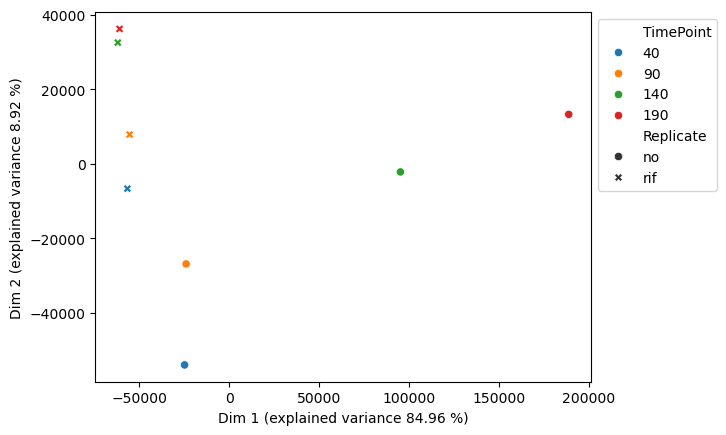

In [20]:
txPCA(tpms.iloc[:,0:tpms.shape[1]-2])

In [21]:
columnOrder = ['40_no_rif', '90_no_rif', '140_no_rif', '190_no_rif', '40_rif', '90_rif', '140_rif', '190_rif']
tpms[columnOrder]

SampleNames,40_no_rif,90_no_rif,140_no_rif,190_no_rif,40_rif,90_rif,140_rif,190_rif
Geneid,,,,,,,,
gene-FLV31_RS18100,12.372040,4.051399,1.394115,1.787902,0.183635,0.101525,0.365877,0.862045
gene-FLV31_RS18840,1.859229,0.418809,0.478096,1.042801,0.018466,0.166754,1.053617,3.091876
gene-FLV31_RS04205,0.372296,0.227629,0.223382,0.045603,0.023419,0.090633,0.148466,0.769565
gene-FLV31_RS02150,112.987063,34.313742,9.978767,5.133587,1.191236,0.226728,0.866606,1.619563
gene-FLV31_RS10635,85.815269,49.536962,15.468039,14.102745,3.955087,11.198157,36.274912,52.966930
...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,33.675030,11.075397,3.609209,4.099687,2.377047,2.365528,3.013864,7.757945
gene-FLV31_RS08465,95.575730,33.181017,12.851947,7.015273,2.064455,0.365534,0.872509,2.216958
gene-FLV31_RS17860,60.604417,55.199941,19.577805,11.013063,1.510537,1.857982,6.458280,10.938813


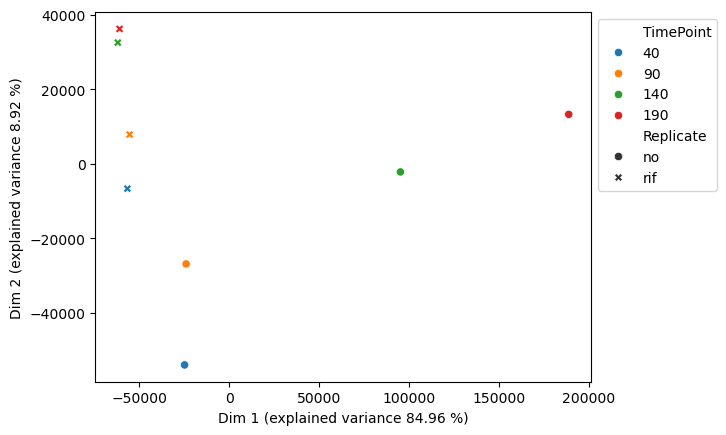

In [22]:
txPCA(tpms[columnOrder]) # PCA is barely affected by order of samples in tpms

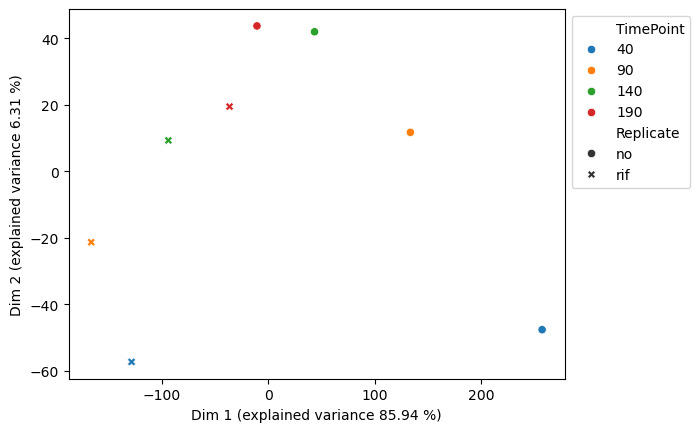

In [23]:
txPCA(logs[columnOrder])

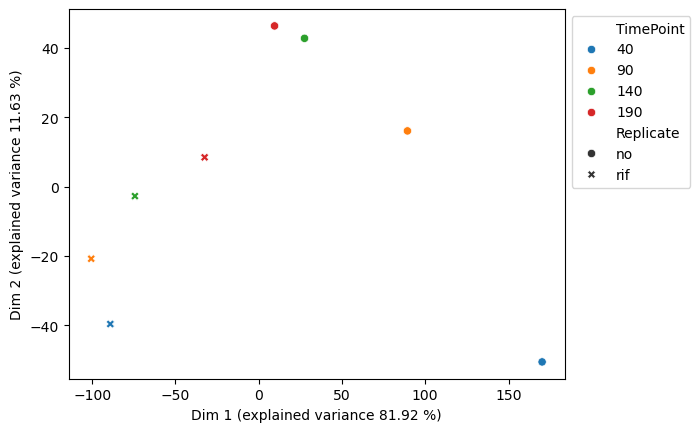

In [24]:
txPCA(logTPMs[columnOrder])

In [25]:
tpmHost = tpms[tpms['Entity'] == 'host']
tpmPhage = tpms[tpms['Entity'] == 'phage']
logTPMsHost = logTPMs[logTPMs['Entity'] == 'host']
logTPMsPhage = logTPMs[logTPMs['Entity'] == 'phage']

tpmHost

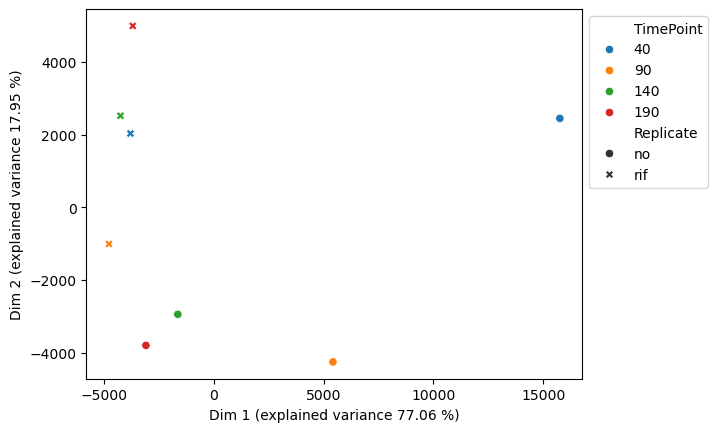

In [26]:
txPCA(tpmHost[columnOrder])

tpmPhage

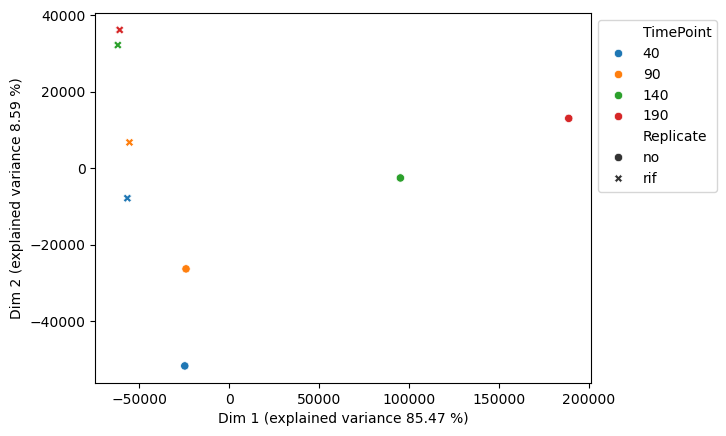

In [27]:
txPCA(tpmPhage[columnOrder])

logTPM Host

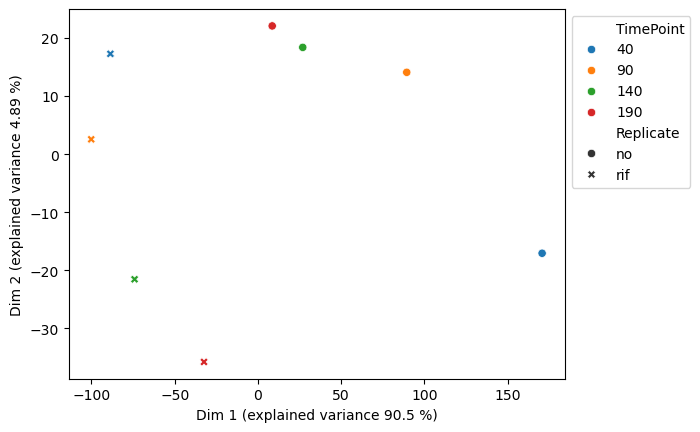

In [28]:
txPCA(logTPMsHost[columnOrder])

logTPM Phage

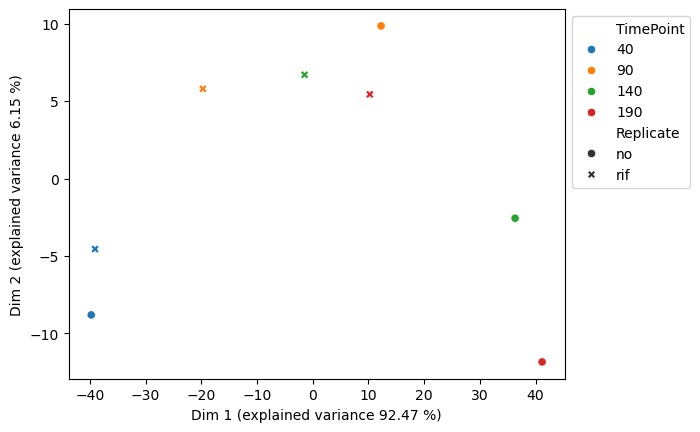

In [29]:
txPCA(logTPMsPhage[columnOrder])

## 4. Final grouping

Split data into both treatments (+/- Rifampicin).

In [30]:
# Without rifampicin
TPMmeans_norif, TPMsds_norif = getMeanSD(tpms[['40_no_rif', '90_no_rif', '140_no_rif', '190_no_rif']])
TPMmeans_norif
TPMmeans_norif = TPMmeans_norif[['40', '90', '140', '190']]
TPMmeans_norif[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
TPMsds_norif = TPMsds_norif[['40', '90', '140', '190']]
TPMsds_norif[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
tpms_norif = tpms[['40_no_rif', '90_no_rif', '140_no_rif', '190_no_rif']]
tpms_norif.columns = ['40', '90', '140', '190']
tpms_norif[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
logTPM_norif = logTPMs[['40_no_rif', '90_no_rif', '140_no_rif', '190_no_rif']]
logTPM_norif.columns = ['40', '90', '140', '190']
logTPM_norif[['Entity', 'Symbol']] = logTPMs[['Entity', 'Symbol']]
raw_norif = df_norRNAs[['40_no_rif', '90_no_rif', '140_no_rif', '190_no_rif']]
raw_norif.columns = ['40', '90', '140', '190']
raw_norif[['Entity', 'Symbol']] = logTPMs[['Entity', 'Symbol']]

# With rifampicin
TPMmeans_rif, TPMsds_rif = getMeanSD(tpms[['40_rif', '90_rif', '140_rif', '190_rif']])
TPMmeans_rif
TPMmeans_rif = TPMmeans_rif[['40', '90', '140', '190']]
TPMmeans_rif[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
TPMsds_rif = TPMsds_rif[['40', '90', '140', '190']]
TPMsds_rif[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
TPMmeans_rif
tpms_rif = tpms[['40_rif', '90_rif', '140_rif', '190_rif']]
tpms_rif.columns = ['40', '90', '140', '190']
tpms_rif[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
logTPM_rif = logTPMs[['40_rif', '90_rif', '140_rif', '190_rif']]
logTPM_rif.columns = ['40', '90', '140', '190']
logTPM_rif[['Entity', 'Symbol']] = logTPMs[['Entity', 'Symbol']]
raw_rif = df_norRNAs[['40_rif', '90_rif', '140_rif', '190_rif']]
raw_rif.columns = ['40', '90', '140', '190']
raw_rif[['Entity', 'Symbol']] = logTPMs[['Entity', 'Symbol']]
raw_rif

,40,90,140,190,Entity,Symbol
Geneid,,,,,,
gene-FLV31_RS18100,3,1,5,10,host,gene-FLV31_RS18100
gene-FLV31_RS18840,0,3,22,53,host,gene-FLV31_RS18840
gene-FLV31_RS04205,0,1,2,10,host,gene-FLV31_RS04205
gene-FLV31_RS02150,30,4,17,26,host,gene-FLV31_RS02150
gene-FLV31_RS10635,38,84,278,329,host,gene-FLV31_RS10635
...,...,...,...,...,...,...
gene-FLV31_RS03935,17,13,17,36,host,gene-FLV31_RS03935
gene-FLV31_RS08465,25,3,8,17,host,gene-FLV31_RS08465
gene-FLV31_RS17860,21,20,72,99,host,gene-FLV31_RS17860


In [31]:
propExp_norif = proportionalExp(TPMmeans_norif[['40', '90', '140', '190']])
propExp_norif[['Entity', 'Symbol']] = TPMmeans_norif[['Entity', 'Symbol']]
propExp_norif

propExp_rif = proportionalExp(TPMmeans_rif[['40', '90', '140', '190']])
propExp_rif[['Entity', 'Symbol']] = TPMmeans_rif[['Entity', 'Symbol']]
propExp_rif

,40,90,140,190,Entity,Symbol
Geneid,,,,,,
gene-FLV31_RS18100,0.213022,0.117772,0.424429,1.0,host,gene-FLV31_RS18100
gene-FLV31_RS18840,0.005973,0.053933,0.340769,1.0,host,gene-FLV31_RS18840
gene-FLV31_RS04205,0.030432,0.117772,0.192922,1.0,host,gene-FLV31_RS04205
gene-FLV31_RS02150,0.735529,0.139993,0.535086,1.0,host,gene-FLV31_RS02150
gene-FLV31_RS10635,0.074671,0.211418,0.684860,1.0,host,gene-FLV31_RS10635
...,...,...,...,...,...,...
gene-FLV31_RS03935,0.306402,0.304917,0.388487,1.0,host,gene-FLV31_RS03935
gene-FLV31_RS08465,0.931211,0.164881,0.393562,1.0,host,gene-FLV31_RS08465
gene-FLV31_RS17860,0.138090,0.169852,0.590400,1.0,host,gene-FLV31_RS17860


## 5. Phage gene classification

In [32]:
# Add a classification label based on exceeding 20 % of maximal expression

def classLabelThreshold(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-2)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM*0.2

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x >= thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('middle')
        elif timePoint == 3:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassThreshold'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassThreshold'] = 'None'

    return tpmOut

In [33]:
# Add a classification label based on exceeding 20 % of maximal expression

def classLabelMax(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-3)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x == thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('middle')
        elif timePoint == 3:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassMax'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassMax'] = 'None'

    return tpmOut

In [34]:
TPMmeans_norif = classLabelThreshold(TPMmeans_norif)
TPMmeans_norif = classLabelMax(TPMmeans_norif)

TPMmeans_rif = classLabelThreshold(TPMmeans_rif)
TPMmeans_rif = classLabelMax(TPMmeans_rif)

In [35]:
TPMmeans_rif

,40,90,140,190,Entity,Symbol,ClassThreshold,ClassMax
Geneid,,,,,,,,
gene-FLV31_RS18100,0.183635,0.101525,0.365877,0.862045,host,gene-FLV31_RS18100,None,None
gene-FLV31_RS18840,0.018466,0.166754,1.053617,3.091876,host,gene-FLV31_RS18840,None,None
gene-FLV31_RS04205,0.023419,0.090633,0.148466,0.769565,host,gene-FLV31_RS04205,None,None
gene-FLV31_RS02150,1.191236,0.226728,0.866606,1.619563,host,gene-FLV31_RS02150,None,None
gene-FLV31_RS10635,3.955087,11.198157,36.274912,52.966930,host,gene-FLV31_RS10635,None,None
...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,2.377047,2.365528,3.013864,7.757945,host,gene-FLV31_RS03935,None,None
gene-FLV31_RS08465,2.064455,0.365534,0.872509,2.216958,host,gene-FLV31_RS08465,None,None
gene-FLV31_RS17860,1.510537,1.857982,6.458280,10.938813,host,gene-FLV31_RS17860,None,None


Add classes to other dfs.

In [36]:
TPMsds_norif[['ClassThreshold', 'ClassMax']] = TPMmeans_norif[['ClassThreshold', 'ClassMax']]
tpms_norif[['ClassThreshold', 'ClassMax']] = TPMmeans_norif[['ClassThreshold', 'ClassMax']]
logTPM_norif[['ClassThreshold', 'ClassMax']] = TPMmeans_norif[['ClassThreshold', 'ClassMax']]
propExp_norif[['ClassThreshold', 'ClassMax']] = TPMmeans_norif[['ClassThreshold', 'ClassMax']]
raw_norif[['ClassThreshold', 'ClassMax']] = TPMmeans_norif[['ClassThreshold', 'ClassMax']]


TPMsds_rif[['ClassThreshold', 'ClassMax']] = TPMmeans_rif[['ClassThreshold', 'ClassMax']]
tpms_rif[['ClassThreshold', 'ClassMax']] = TPMmeans_rif[['ClassThreshold', 'ClassMax']]
logTPM_rif[['ClassThreshold', 'ClassMax']] = TPMmeans_rif[['ClassThreshold', 'ClassMax']]
propExp_rif[['ClassThreshold', 'ClassMax']] = TPMmeans_rif[['ClassThreshold', 'ClassMax']]
raw_rif[['ClassThreshold', 'ClassMax']] = TPMmeans_rif[['ClassThreshold', 'ClassMax']]

# gff3
gff3_final_rif = gff3_genes.merge(TPMmeans_rif[["ClassThreshold", "ClassMax"]], right_index=True, left_on="ID", how="left")
gff3_host_rif  = gff3_final_rif[gff3_final_rif['seq_id'] != 'NC_021806.1']
gff3_phage_rif = gff3_final_rif[gff3_final_rif['seq_id'] == 'NC_021806.1']

gff3_final_norif = gff3_genes.merge(TPMmeans_norif[["ClassThreshold", "ClassMax"]], right_index=True, left_on="ID", how="left")
gff3_host_norif  = gff3_final_norif[gff3_final_norif['seq_id'] != 'NC_021806.1']
gff3_phage_norif = gff3_final_norif[gff3_final_norif['seq_id'] == 'NC_021806.1']

## 6. Add variance to all dataframes

Base variance call on tpms.

In [37]:
def stabilizedVariance(df):
    labels = list()
    
    i = 0
    while i < df.shape[0]:

        # Get array of expression values at time points
        expressions = list(df.iloc[i,0:(df.shape[1]-4)])

        # Get mean expression for the gene
        exprMean = np.mean(np.array(expressions))

        # Get the variance for the gene
        varGene = np.var(np.array(expressions))

        # Stabilized variance
        stableVarGene = varGene/exprMean

        labels.append(stableVarGene)

        i += 1

    tpmOut = df.copy()
    tpmOut['Variance'] = labels

    return tpmOut

In [38]:
tpms_norif = stabilizedVariance(tpms_norif)
tpms_norif

,40,90,140,190,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,
gene-FLV31_RS18100,12.372040,4.051399,1.394115,1.787902,host,gene-FLV31_RS18100,None,None,4.005410
gene-FLV31_RS18840,1.859229,0.418809,0.478096,1.042801,host,gene-FLV31_RS18840,None,None,0.352774
gene-FLV31_RS04205,0.372296,0.227629,0.223382,0.045603,host,gene-FLV31_RS04205,None,None,0.061741
gene-FLV31_RS02150,112.987063,34.313742,9.978767,5.133587,host,gene-FLV31_RS02150,None,None,46.024166
gene-FLV31_RS10635,85.815269,49.536962,15.468039,14.102745,host,gene-FLV31_RS10635,None,None,20.957769
...,...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,33.675030,11.075397,3.609209,4.099687,host,gene-FLV31_RS03935,None,None,11.409044
gene-FLV31_RS08465,95.575730,33.181017,12.851947,7.015273,host,gene-FLV31_RS08465,None,None,33.156266
gene-FLV31_RS17860,60.604417,55.199941,19.577805,11.013063,host,gene-FLV31_RS17860,None,None,12.750527


In [39]:
tpms_rif = stabilizedVariance(tpms_rif)
tpms_rif

,40,90,140,190,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,
gene-FLV31_RS18100,0.183635,0.101525,0.365877,0.862045,host,gene-FLV31_RS18100,None,None,0.230432
gene-FLV31_RS18840,0.018466,0.166754,1.053617,3.091876,host,gene-FLV31_RS18840,None,None,1.387574
gene-FLV31_RS04205,0.023419,0.090633,0.148466,0.769565,host,gene-FLV31_RS04205,None,None,0.345646
gene-FLV31_RS02150,1.191236,0.226728,0.866606,1.619563,host,gene-FLV31_RS02150,None,None,0.264816
gene-FLV31_RS10635,3.955087,11.198157,36.274912,52.966930,host,gene-FLV31_RS10635,None,None,14.730797
...,...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,2.377047,2.365528,3.013864,7.757945,host,gene-FLV31_RS03935,None,None,1.311115
gene-FLV31_RS08465,2.064455,0.365534,0.872509,2.216958,host,gene-FLV31_RS08465,None,None,0.444911
gene-FLV31_RS17860,1.510537,1.857982,6.458280,10.938813,host,gene-FLV31_RS17860,None,None,2.855594


In [40]:
logTPM_norif['Variance'] = tpms_norif['Variance']
TPMmeans_norif['Variance'] = tpms_norif['Variance']
TPMsds_norif['Variance'] = tpms_norif['Variance']
propExp_norif['Variance'] = tpms_norif['Variance']
raw_norif['Variance'] = tpms_norif['Variance']

In [41]:
logTPM_rif['Variance'] = tpms_rif['Variance']
TPMmeans_rif['Variance'] = tpms_rif['Variance']
TPMsds_rif['Variance'] = tpms_rif['Variance']
propExp_rif['Variance'] = tpms_rif['Variance']
raw_rif['Variance'] = tpms_rif['Variance']

In [42]:
propExp_norif

,40,90,140,190,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,
gene-FLV31_RS18100,1.0,0.327464,0.112683,0.144511,host,gene-FLV31_RS18100,None,None,4.005410
gene-FLV31_RS18840,1.0,0.225260,0.257148,0.560878,host,gene-FLV31_RS18840,None,None,0.352774
gene-FLV31_RS04205,1.0,0.611419,0.600011,0.122491,host,gene-FLV31_RS04205,None,None,0.061741
gene-FLV31_RS02150,1.0,0.303696,0.088318,0.045435,host,gene-FLV31_RS02150,None,None,46.024166
gene-FLV31_RS10635,1.0,0.577251,0.180248,0.164338,host,gene-FLV31_RS10635,None,None,20.957769
...,...,...,...,...,...,...,...,...,...
gene-FLV31_RS03935,1.0,0.328890,0.107178,0.121743,host,gene-FLV31_RS03935,None,None,11.409044
gene-FLV31_RS08465,1.0,0.347170,0.134469,0.073400,host,gene-FLV31_RS08465,None,None,33.156266
gene-FLV31_RS17860,1.0,0.910824,0.323043,0.181720,host,gene-FLV31_RS17860,None,None,12.750527


## 7. Write data to output

In [44]:
# FIRST FOR NO RIF DATA

# Full TPM table
tpms_rif.to_csv('Drobysheva_2021_no_rifampicin_full_TPM.tsv', sep = '\t')
# Full raw_counts table
raw_norif.to_csv('Drobysheva_2021_no_rifampicin_full_raw_counts.tsv', sep = '\t')
# Summarized (time point means) TPM table
TPMmeans_norif.to_csv('Drobysheva_2021_no_rifampicin_TPM_means.tsv', sep = '\t')
# Summarized (time point) TPM standard deviation
TPMsds_norif.to_csv('Drobysheva_2021_no_rifampicin_TPM_std.tsv', sep = '\t')
# Proportional expression per gene and time point
propExp_norif.to_csv('Drobysheva_2021_no_rifampicin_fractional_expresssion.tsv', sep = '\t')
# Processed gff3 file
gff3_host_norif.to_csv('Drobysheva_2021_host_gff3_no_rifampicin.tsv', sep='\t')
gff3_phage_norif.to_csv('Drobysheva_2021_phage_gff3_no_rifampicin.tsv', sep='\t')

# SECOND FOR RIF DATA

# Full TPM table
tpms_rif.to_csv('Drobysheva_2021_plus_rifampicin_full_TPM.tsv', sep = '\t')
# Full raw_counts table
raw_rif.to_csv('Drobysheva_2021_plus_rifampicin_full_raw_counts.tsv', sep = '\t')
# Summarized (time point means) TPM table
TPMmeans_rif.to_csv('Drobysheva_2021_plus_rifampicin_TPM_means.tsv', sep = '\t')
# Summarized (time point) TPM standard deviation
TPMsds_rif.to_csv('Drobysheva_2021_plus_rifampicin_TPM_std.tsv', sep = '\t')
# Proportional expression per gene and time point
propExp_rif.to_csv('Drobysheva_2021_plus_rifampicin_fractional_expresssion.tsv', sep = '\t')
# Processed gff3 file
gff3_host_rif.to_csv('Drobysheva_2021_host_gff3_plus_rifampicin.tsv', sep='\t')
gff3_phage_rif.to_csv('Drobysheva_2021_phage_gff3_plus_rifampicin.tsv', sep='\t')